# Wafer Map Anomaly Detection (Normal-Only Training)

This notebook builds an anomaly detector using a convolutional autoencoder.
- Train only on normal wafers (`failureType == none`)
- Learn a reconstruction-error threshold from normal validation data
- Test on both normal and defective wafers

In [12]:
# Core imports
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

In [13]:
# Reproducibility and device
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)
torch.cuda.empty_cache()

Using device: cuda


In [ ]:
# Configuration
DATA_PATH = 'data/raw/LSWMD.pkl'
IMAGE_SIZE = 64
BATCH_SIZE = 128
LR = 1e-3
EPOCHS = 12
ANOMALY_PERCENTILE = 99  # threshold percentile from validation-normal reconstruction errors

# Optional caps for faster experiments (set to None to use all)
MAX_NORMAL_SAMPLES = 40000
MAX_DEFECT_SAMPLES = 300

In [15]:
# Load data
df = pd.read_pickle(DATA_PATH)
print('Raw shape:', df.shape)
df.head(20)

Raw shape: (811457, 6)


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]
5,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,6.0,[[Training]],[[none]]
6,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,7.0,[[Training]],[[none]]
7,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,8.0,[[Training]],[[none]]
8,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,9.0,[[Training]],[[none]]
9,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,10.0,[[Training]],[[none]]


In [16]:
# Parse labels and keep only labeled wafers
def parse_failure_label(value):
    if value is None:
        return 'unknown'
    if isinstance(value, float) and np.isnan(value):
        return 'unknown'
    if isinstance(value, (list, tuple, np.ndarray)):
        arr = np.array(value).reshape(-1)
        if len(arr) == 0:
            return 'unknown'
        return str(arr[0])
    return str(value)

df = df.copy()
df['failure_label'] = df['failureType'].apply(parse_failure_label)
invalid = {'0', 'unknown', 'nan', 'None', '[]'}
df = df[~df['failure_label'].isin(invalid)].copy()

df['failure_label'] = df['failure_label'].str.strip()
# Labeling rule for anomaly detection:
# failure_label == 'none'  -> normal wafer (is_anomaly = 0)
# failure_label != 'none'  -> defect wafer (is_anomaly = 1)
# Invalid or unlabeled rows were removed above.
df['is_anomaly'] = (df['failure_label'].str.lower() != 'none').astype(int)

normal_df = df[df['is_anomaly'] == 0].copy()
defect_df = df[df['is_anomaly'] == 1].copy()

if MAX_NORMAL_SAMPLES is not None and len(normal_df) > MAX_NORMAL_SAMPLES:
    normal_df = normal_df.sample(n=MAX_NORMAL_SAMPLES, random_state=SEED)
if MAX_DEFECT_SAMPLES is not None and len(defect_df) > MAX_DEFECT_SAMPLES:
    defect_df = defect_df.sample(n=MAX_DEFECT_SAMPLES, random_state=SEED)

print('Labeled data shape:', df.shape)
print('Normal wafers:', len(normal_df))
print('Defect wafers:', len(defect_df))
display(df['failure_label'].value_counts().head(12))

Labeled data shape: (172950, 8)
Normal wafers: 40000
Defect wafers: 25000


failure_label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

In [17]:
# Convert wafer map to 3-channel one-hot tensor and resize
def wafer_to_tensor(wafer_map, size=64):
    arr = np.array(wafer_map, dtype=np.int64)
    arr = np.clip(arr, 0, 2)
    x = torch.tensor(arr, dtype=torch.long)
    x = F.one_hot(x, num_classes=3).permute(2, 0, 1).float()  # (3, H, W)
    x = x.unsqueeze(0)
    x = F.interpolate(x, size=(size, size), mode='nearest')
    return x.squeeze(0)

def build_tensor(frame, size=64):
    imgs = [wafer_to_tensor(w, size=size) for w in frame['waferMap'].values]
    X = torch.stack(imgs)
    y = torch.tensor(frame['is_anomaly'].values, dtype=torch.long)
    labels = frame['failure_label'].values
    return X, y, labels

# Split normal wafers: train/val/test
normal_train_df, normal_temp_df = train_test_split(normal_df, test_size=0.30, random_state=SEED, shuffle=True)
normal_val_df, normal_test_df = train_test_split(normal_temp_df, test_size=0.50, random_state=SEED, shuffle=True)

# Defects are used only for test
defect_test_df = defect_df.copy()

X_train, y_train, _ = build_tensor(normal_train_df, IMAGE_SIZE)
X_val, y_val, _ = build_tensor(normal_val_df, IMAGE_SIZE)
X_test_normal, y_test_normal, _ = build_tensor(normal_test_df, IMAGE_SIZE)
X_test_defect, y_test_defect, defect_names = build_tensor(defect_test_df, IMAGE_SIZE)

print('Train normal:', X_train.shape)
print('Val normal:', X_val.shape)
print('Test normal:', X_test_normal.shape)
print('Test defect:', X_test_defect.shape)

Train normal: torch.Size([28000, 3, 64, 64])
Val normal: torch.Size([6000, 3, 64, 64])
Test normal: torch.Size([6000, 3, 64, 64])
Test defect: torch.Size([25000, 3, 64, 64])


In [18]:
# Dataloaders (train only sees normal wafers)
train_loader = DataLoader(TensorDataset(X_train, X_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, X_val), batch_size=BATCH_SIZE, shuffle=False)

print('Train batches:', len(train_loader), '| Val batches:', len(val_loader))

Train batches: 219 | Val batches: 47


In [19]:
# --- LEVER 2 + 3: Improved architecture with BatchNorm and LEVER 4: SSIM+MSE loss ---
# BatchNorm: stabilises training, helps the encoder learn sharper features
#            → normal wafers get very low error, defects get higher error  (wider gap → ↑TP + ↑TN)
# SSIM loss: structural similarity captures edge/pattern differences MSE misses
#            → autoencoder can no longer "blur past" defect patterns (↑TP)

from pytorch_msssim import ssim   # pip install pytorch-msssim

class ImprovedAutoEncoder(nn.Module):
    """Deeper encoder with BatchNorm + Dropout for better TP/TN separation."""
    def __init__(self, dropout=0.1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),   nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2),                                                       # 56→28
            nn.Conv2d(32, 64, 3, padding=1),  nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),  nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2),                                                       # 28→14
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),                                                       # 14→7
            nn.Dropout2d(dropout),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 2, stride=2), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 2, stride=2),  nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 2, stride=2),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


def ssim_mse_loss(pred, target, alpha=0.5):
    """Combined MSE + (1-SSIM) loss. alpha controls the SSIM weight."""
    mse = F.mse_loss(pred, target)
    ssim_val = ssim(pred, target, data_range=1.0, size_average=True)
    return (1 - alpha) * mse + alpha * (1 - ssim_val)


model_v2 = ImprovedAutoEncoder(dropout=0.1).to(DEVICE)
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=LR)

# Cosine annealing LR: decays smoothly → avoids late-epoch instability (↑TN)
EPOCHS_V2 = 30
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_v2, T_max=EPOCHS_V2, eta_min=1e-5)

print(model_v2)
print(f"\nTraining for {EPOCHS_V2} epochs with SSIM+MSE loss + cosine LR schedule")


ImprovedAutoEncoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), pa

Epoch 01/30 | train=0.384619 | val=0.136766 | lr=9.97e-04
Epoch 05/30 | train=0.042531 | val=0.026935 | lr=9.34e-04
Epoch 10/30 | train=0.028284 | val=0.015522 | lr=7.53e-04
Epoch 15/30 | train=0.022938 | val=0.012040 | lr=5.05e-04
Epoch 20/30 | train=0.020087 | val=0.009980 | lr=2.58e-04
Epoch 25/30 | train=0.018672 | val=0.008916 | lr=7.63e-05
Epoch 30/30 | train=0.018236 | val=0.008628 | lr=1.00e-05

Best val loss: 0.008628


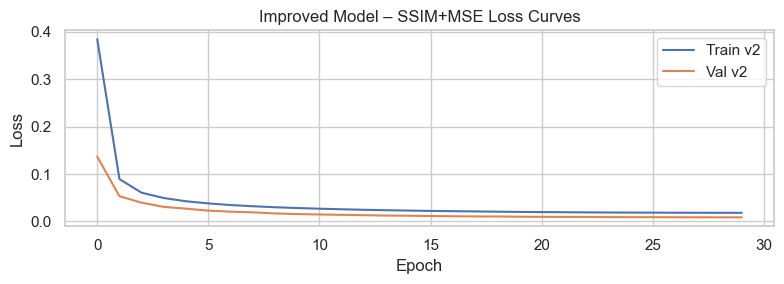

In [20]:
# --- LEVER 5: Augmentation + full training loop for improved model ---
# H/V flips and 90° rotations are valid for wafer maps (rotationally symmetric)
# → normal wafers are seen in more orientations → fewer FP from orientation artifacts

import torchvision.transforms.functional as TF

def augment_wafer(x):
    """Random horizontal flip + vertical flip + 90° rotation."""
    if torch.rand(1) > 0.5:
        x = TF.hflip(x)
    if torch.rand(1) > 0.5:
        x = TF.vflip(x)
    k = torch.randint(0, 4, (1,)).item()
    if k > 0:
        x = torch.rot90(x, k, dims=[1, 2])
    return x

train_losses_v2, val_losses_v2 = [], []
best_val = float('inf')

for epoch in range(1, EPOCHS_V2 + 1):
    model_v2.train()
    running = 0.0
    for xb, _ in train_loader:
        # Apply augmentation batch-wise
        xb_aug = torch.stack([augment_wafer(img) for img in xb]).to(DEVICE)
        optimizer_v2.zero_grad()
        pred = model_v2(xb_aug)
        loss = ssim_mse_loss(pred, xb_aug)
        loss.backward()
        optimizer_v2.step()
        running += loss.item() * xb_aug.size(0)

    epoch_train = running / len(train_loader.dataset)

    model_v2.eval()
    running_val = 0.0
    with torch.no_grad():
        for xb, _ in val_loader:
            xb = xb.to(DEVICE)
            pred = model_v2(xb)
            running_val += ssim_mse_loss(pred, xb).item() * xb.size(0)
    epoch_val = running_val / len(val_loader.dataset)

    scheduler.step()
    train_losses_v2.append(epoch_train)
    val_losses_v2.append(epoch_val)

    if epoch_val < best_val:
        best_val = epoch_val
        torch.save(model_v2.state_dict(), 'wafer_anomaly_autoencoder_v2_best.pt')

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{EPOCHS_V2} | train={epoch_train:.6f} | val={epoch_val:.6f} | lr={scheduler.get_last_lr()[0]:.2e}")

# Load best weights
model_v2.load_state_dict(torch.load('wafer_anomaly_autoencoder_v2_best.pt', map_location=DEVICE))
print(f"\nBest val loss: {best_val:.6f}")

plt.figure(figsize=(8, 3))
plt.plot(train_losses_v2, label='Train v2')
plt.plot(val_losses_v2, label='Val v2')
plt.title('Improved Model – SSIM+MSE Loss Curves')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout(); plt.show()


model_v2 threshold @ P99: 0.019334
ROC-AUC (error score): 0.8619
              precision    recall  f1-score   support

      normal       0.21      0.99      0.35      6000
     anomaly       0.98      0.13      0.22     25000

    accuracy                           0.29     31000
   macro avg       0.60      0.56      0.29     31000
weighted avg       0.83      0.29      0.25     31000



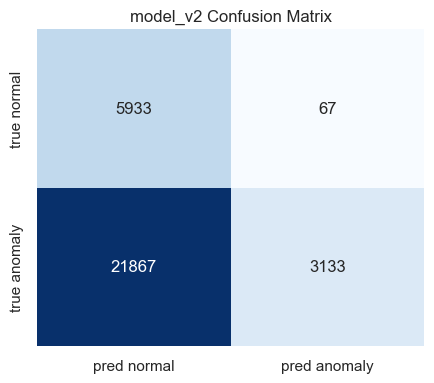

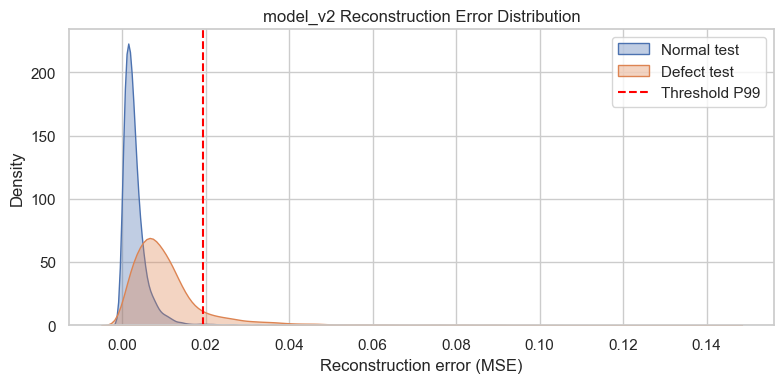

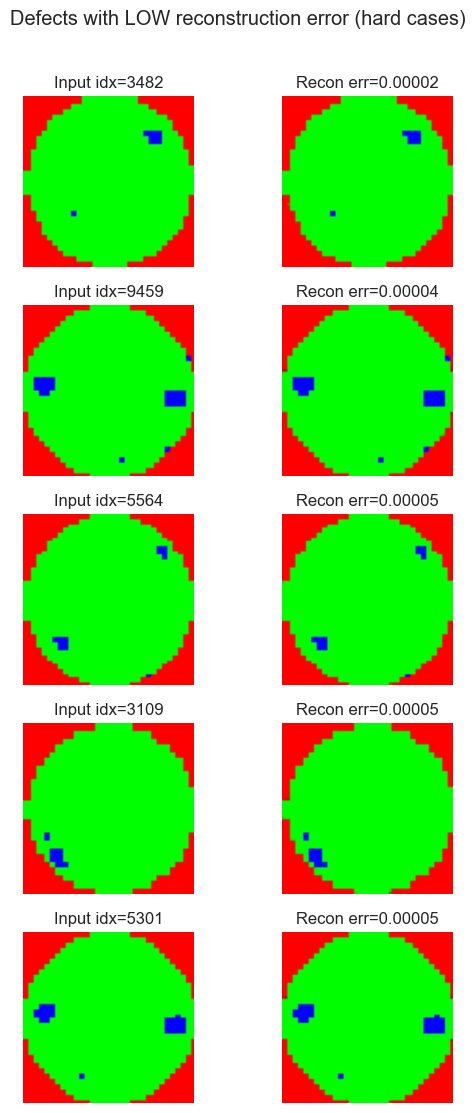

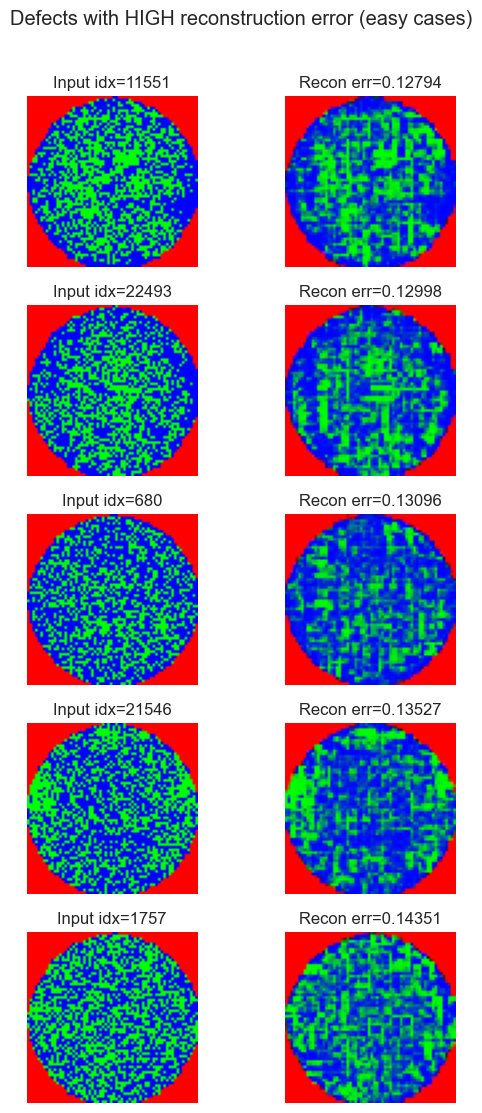

In [21]:
# --- Review cell: evaluate model_v2 on normal vs defect wafers ---
def reconstruction_error_batch(model, x, batch_size=256):
    """Per-sample MSE reconstruction error."""
    model.eval()
    errs = []
    with torch.no_grad():
        for i in range(0, len(x), batch_size):
            xb = x[i:i + batch_size].to(DEVICE)
            recon = model(xb)
            e = ((recon - xb) ** 2).mean(dim=(1, 2, 3))
            errs.append(e.detach().cpu())
    return torch.cat(errs).numpy()

# 1) Compute reconstruction errors
val_err_v2 = reconstruction_error_batch(model_v2, X_val)
test_normal_err_v2 = reconstruction_error_batch(model_v2, X_test_normal)
test_defect_err_v2 = reconstruction_error_batch(model_v2, X_test_defect)

# 2) Threshold from normal validation errors
threshold_v2 = np.percentile(val_err_v2, ANOMALY_PERCENTILE)

# 3) Build test set and predict
y_true_v2 = np.concatenate([np.zeros(len(test_normal_err_v2), dtype=int), np.ones(len(test_defect_err_v2), dtype=int)])
scores_v2 = np.concatenate([test_normal_err_v2, test_defect_err_v2])
y_pred_v2 = (scores_v2 > threshold_v2).astype(int)

print(f"model_v2 threshold @ P{ANOMALY_PERCENTILE}: {threshold_v2:.6f}")
print(f"ROC-AUC (error score): {roc_auc_score(y_true_v2, scores_v2):.4f}")
print(classification_report(y_true_v2, y_pred_v2, target_names=['normal', 'anomaly']))

# 4) Confusion matrix
cm_v2 = confusion_matrix(y_true_v2, y_pred_v2)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pred normal', 'pred anomaly'],
            yticklabels=['true normal', 'true anomaly'])
plt.title('model_v2 Confusion Matrix')
plt.tight_layout(); plt.show()

# 5) Error distribution
plt.figure(figsize=(8, 4))
sns.kdeplot(test_normal_err_v2, label='Normal test', fill=True, alpha=0.35)
sns.kdeplot(test_defect_err_v2, label='Defect test', fill=True, alpha=0.35)
plt.axvline(threshold_v2, color='red', linestyle='--', label=f'Threshold P{ANOMALY_PERCENTILE}')
plt.xlabel('Reconstruction error (MSE)')
plt.ylabel('Density')
plt.title('model_v2 Reconstruction Error Distribution')
plt.legend()
plt.tight_layout(); plt.show()

# 6) Quick qualitative review: show best/worst reconstructions for defects
n_show = 5
worst_idx = np.argsort(test_defect_err_v2)[-n_show:]
best_idx = np.argsort(test_defect_err_v2)[:n_show]

def show_recon_examples(indices, title):
    x = X_test_defect[indices].to(DEVICE)
    with torch.no_grad():
        recon = model_v2(x).cpu()
    x = x.cpu()

    fig, axes = plt.subplots(len(indices), 2, figsize=(6, 2.2 * len(indices)))
    if len(indices) == 1:
        axes = np.expand_dims(axes, axis=0)

    for r, idx in enumerate(indices):
        axes[r, 0].imshow(x[r].permute(1, 2, 0).numpy())
        axes[r, 0].set_title(f'Input idx={idx}')
        axes[r, 0].axis('off')

        axes[r, 1].imshow(recon[r].permute(1, 2, 0).numpy())
        axes[r, 1].set_title(f'Recon err={test_defect_err_v2[idx]:.5f}')
        axes[r, 1].axis('off')

    fig.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.show()

show_recon_examples(best_idx, 'Defects with LOW reconstruction error (hard cases)')
show_recon_examples(worst_idx, 'Defects with HIGH reconstruction error (easy cases)')

LNSA setup: normal=5000, anomaly=250
Best threshold (by F1 on LNSA): 0.00798978
Best metrics -> precision=0.3025, recall=0.5360, f1=0.3867

Baseline threshold_v2 @ P99: 0.01933359
Baseline metrics:
              precision    recall  f1-score   support

      normal       0.96      0.99      0.97      5000
     anomaly       0.31      0.10      0.16       250

    accuracy                           0.95      5250
   macro avg       0.63      0.55      0.56      5250
weighted avg       0.93      0.95      0.93      5250


Best-threshold metrics:
              precision    recall  f1-score   support

      normal       0.98      0.94      0.96      5000
     anomaly       0.30      0.54      0.39       250

    accuracy                           0.92      5250
   macro avg       0.64      0.74      0.67      5250
weighted avg       0.94      0.92      0.93      5250



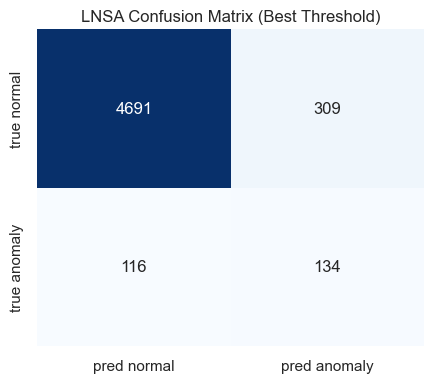

,threshold,precision,recall,f1,fp_rate,tp_rate
0,0.007990,0.302483,0.536,0.386724,0.058857,0.025524
1,0.007983,0.301802,0.536,0.386167,0.059048,0.025524
2,0.007961,0.301124,0.536,0.385612,0.059238,0.025524
3,0.008017,0.300905,0.532,0.384393,0.058857,0.025333
4,0.007883,0.298013,0.540,0.384068,0.060571,0.025714
5,0.007926,0.299107,0.536,0.383954,0.059810,0.025524
6,0.007861,0.297357,0.540,0.383523,0.060762,0.025714
7,0.007912,0.298441,0.536,0.383405,0.060000,0.025524
8,0.007849,0.296053,0.540,0.382436,0.061143,0.025714
9,0.007895,0.297118,0.536,0.382311,0.060381,0.025524


In [42]:
# --- Threshold tuning for Large-Normal / Small-Anomaly (LNSA) scenario ---
from sklearn.metrics import precision_score, recall_score, f1_score

# Recompute errors if this kernel state does not already contain them.
if 'val_err_v2' not in globals() or 'test_normal_err_v2' not in globals() or 'test_defect_err_v2' not in globals():
    val_err_v2 = reconstruction_error_batch(model_v2, X_val)
    test_normal_err_v2 = reconstruction_error_batch(model_v2, X_test_normal)
    test_defect_err_v2 = reconstruction_error_batch(model_v2, X_test_defect)

# Fixed LNSA evaluation sizes requested.
N_NORMAL_LARGE = 5000
N_ANOM_SMALL = 250

if N_NORMAL_LARGE > len(test_normal_err_v2):
    N_NORMAL_LARGE = len(test_normal_err_v2)
if N_ANOM_SMALL > len(test_defect_err_v2):
    N_ANOM_SMALL = len(test_defect_err_v2)

rng = globals().get('RNG', np.random.default_rng(SEED))
normal_idx_lnsa = rng.choice(len(test_normal_err_v2), size=N_NORMAL_LARGE, replace=False)
anomaly_idx_lnsa = rng.choice(len(test_defect_err_v2), size=N_ANOM_SMALL, replace=False)

normal_scores_lnsa = test_normal_err_v2[normal_idx_lnsa]
anomaly_scores_lnsa = test_defect_err_v2[anomaly_idx_lnsa]

scores_lnsa = np.concatenate([normal_scores_lnsa, anomaly_scores_lnsa])
y_true_lnsa = np.concatenate([
    np.zeros(len(normal_scores_lnsa), dtype=int),
    np.ones(len(anomaly_scores_lnsa), dtype=int)
])

# Build a robust threshold search space using validation-normal error distribution.
q_grid = np.linspace(90.0, 99.95, 320)
threshold_grid = np.unique(np.percentile(val_err_v2, q_grid))

rows = []
for t in threshold_grid:
    y_pred_lnsa_curr = (scores_lnsa > t).astype(int)
    rows.append({
        'threshold': float(t),
        'precision': precision_score(y_true_lnsa, y_pred_lnsa_curr, zero_division=0),
        'recall': recall_score(y_true_lnsa, y_pred_lnsa_curr, zero_division=0),
        'f1': f1_score(y_true_lnsa, y_pred_lnsa_curr, zero_division=0),
        'fp_rate': np.mean((y_pred_lnsa_curr == 1) & (y_true_lnsa == 0)),
        'tp_rate': np.mean((y_pred_lnsa_curr == 1) & (y_true_lnsa == 1))
    })

thr_df = pd.DataFrame(rows).sort_values(['f1', 'recall', 'precision'], ascending=[False, False, False]).reset_index(drop=True)
best_row = thr_df.iloc[0]
best_threshold_v2 = float(best_row['threshold'])

y_pred_lnsa_best = (scores_lnsa > best_threshold_v2).astype(int)
cm_lnsa_best = confusion_matrix(y_true_lnsa, y_pred_lnsa_best)

print(f'LNSA setup: normal={N_NORMAL_LARGE}, anomaly={N_ANOM_SMALL}')
print(f'Best threshold (by F1 on LNSA): {best_threshold_v2:.8f}')
print(f"Best metrics -> precision={best_row['precision']:.4f}, recall={best_row['recall']:.4f}, f1={best_row['f1']:.4f}")

if 'threshold_v2' in globals():
    y_pred_base = (scores_lnsa > threshold_v2).astype(int)
    print(f'\nBaseline threshold_v2 @ P{ANOMALY_PERCENTILE}: {threshold_v2:.8f}')
    print('Baseline metrics:')
    print(classification_report(y_true_lnsa, y_pred_base, target_names=['normal', 'anomaly']))

print('\nBest-threshold metrics:')
print(classification_report(y_true_lnsa, y_pred_lnsa_best, target_names=['normal', 'anomaly']))

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm_lnsa_best, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pred normal', 'pred anomaly'],
            yticklabels=['true normal', 'true anomaly'])
plt.title('LNSA Confusion Matrix (Best Threshold)')
plt.tight_layout(); plt.show()

display(thr_df.head(10))

## Knowledge Distillation (Teacher -> Student) for Better Anomaly Detection

This section distills the stronger `model_v2` teacher into a lighter student autoencoder.
- Train student on normal wafers using three losses:
  1. Student reconstruction loss
  2. Output distillation (student reconstruction should match teacher reconstruction)
  3. Feature distillation (student bottleneck should mimic teacher bottleneck)
- Use a hybrid anomaly score for inference:
  - student reconstruction error
  - teacher-student feature discrepancy

Goal: better defect separation while keeping the inference model smaller/faster.

In [46]:
# KD setup: student model + distillation losses
from sklearn.metrics import precision_score, recall_score, f1_score

if 'model_v2' not in globals():
    raise RuntimeError('model_v2 (teacher) not found. Run teacher training cells first.')

teacher = model_v2.to(DEVICE)
teacher.eval()
for p in teacher.parameters():
    p.requires_grad = False

class StudentAutoEncoder(nn.Module):
    """Smaller autoencoder distilled from teacher."""
    def __init__(self, dropout=0.05):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2),  # 64->32
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),  # 32->16
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),  # 16->8
            nn.Dropout2d(dropout),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 2, stride=2), nn.BatchNorm2d(16), nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 2, stride=2),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out, z

def distill_feature_loss(z_student, z_teacher):
    # Match channel count with adaptive pooling + pointwise projection via mean when needed.
    if z_student.shape[2:] != z_teacher.shape[2:]:
        z_teacher = F.adaptive_avg_pool2d(z_teacher, z_student.shape[2:])
    if z_teacher.shape[1] != z_student.shape[1]:
        # Cheap channel alignment without extra trainable params.
        z_teacher = z_teacher.mean(dim=1, keepdim=True).repeat(1, z_student.shape[1], 1, 1)
    return F.mse_loss(z_student, z_teacher)

KD_EPOCHS = 16
KD_LR = 5e-4
KD_ALPHA_RECON = 0.55
KD_BETA_OUT = 0.25
KD_GAMMA_FEAT = 0.20

student = StudentAutoEncoder(dropout=0.05).to(DEVICE)
optimizer_kd = torch.optim.Adam(student.parameters(), lr=KD_LR)
scheduler_kd = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_kd, T_max=KD_EPOCHS, eta_min=1e-5)

print(student)
print(f'KD epochs={KD_EPOCHS}, lr={KD_LR}, weights=(recon={KD_ALPHA_RECON}, out={KD_BETA_OUT}, feat={KD_GAMMA_FEAT})')

StudentAutoEncoder(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Dropout2d(p=0.05, inplace=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (1): BatchNorm2d(3

Epoch 01/16 | train=0.174446 | val=0.102439 | lr=4.95e-04
Epoch 04/16 | train=0.054567 | val=0.047688 | lr=4.28e-04
Epoch 08/16 | train=0.046833 | val=0.040058 | lr=2.55e-04
Epoch 12/16 | train=0.042824 | val=0.035934 | lr=8.18e-05
Epoch 16/16 | train=0.041857 | val=0.035074 | lr=1.00e-05
Best KD val loss: 0.035074


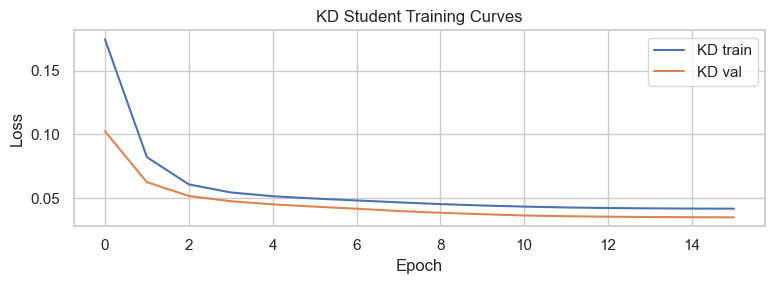

In [44]:
# KD training on normal wafers
student_train_losses, student_val_losses = [], []
best_kd_val = float('inf')

for epoch in range(1, KD_EPOCHS + 1):
    student.train()
    running = 0.0

    for xb, _ in train_loader:
        xb = xb.to(DEVICE)
        xb_aug = torch.stack([augment_wafer(img) for img in xb]).to(DEVICE) if 'augment_wafer' in globals() else xb

        with torch.no_grad():
            t_recon = teacher(xb_aug)
            t_feat = teacher.encoder(xb_aug)

        s_recon, s_feat = student(xb_aug)
        loss_recon = F.mse_loss(s_recon, xb_aug)
        loss_out = F.mse_loss(s_recon, t_recon)
        loss_feat = distill_feature_loss(s_feat, t_feat)

        loss = KD_ALPHA_RECON * loss_recon + KD_BETA_OUT * loss_out + KD_GAMMA_FEAT * loss_feat

        optimizer_kd.zero_grad()
        loss.backward()
        optimizer_kd.step()

        running += loss.item() * xb_aug.size(0)

    epoch_train = running / len(train_loader.dataset)

    student.eval()
    running_val = 0.0
    with torch.no_grad():
        for xb, _ in val_loader:
            xb = xb.to(DEVICE)
            t_recon = teacher(xb)
            t_feat = teacher.encoder(xb)
            s_recon, s_feat = student(xb)

            loss_recon = F.mse_loss(s_recon, xb)
            loss_out = F.mse_loss(s_recon, t_recon)
            loss_feat = distill_feature_loss(s_feat, t_feat)
            kd_val_loss = KD_ALPHA_RECON * loss_recon + KD_BETA_OUT * loss_out + KD_GAMMA_FEAT * loss_feat

            running_val += kd_val_loss.item() * xb.size(0)

    epoch_val = running_val / len(val_loader.dataset)
    scheduler_kd.step()

    student_train_losses.append(epoch_train)
    student_val_losses.append(epoch_val)

    if epoch_val < best_kd_val:
        best_kd_val = epoch_val
        torch.save(student.state_dict(), 'wafer_anomaly_kd_student_best.pt')

    if epoch == 1 or epoch % 4 == 0:
        print(f'Epoch {epoch:02d}/{KD_EPOCHS} | train={epoch_train:.6f} | val={epoch_val:.6f} | lr={scheduler_kd.get_last_lr()[0]:.2e}')

student.load_state_dict(torch.load('wafer_anomaly_kd_student_best.pt', map_location=DEVICE))
print(f'Best KD val loss: {best_kd_val:.6f}')

plt.figure(figsize=(8, 3))
plt.plot(student_train_losses, label='KD train')
plt.plot(student_val_losses, label='KD val')
plt.title('KD Student Training Curves')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout(); plt.show()

KD threshold @ P99: 1.502997
KD ROC-AUC: 0.2430
              precision    recall  f1-score   support

      normal       0.19      0.99      0.32      6000
     anomaly       0.22      0.00      0.00     25000

    accuracy                           0.19     31000
   macro avg       0.21      0.50      0.16     31000
weighted avg       0.21      0.19      0.06     31000



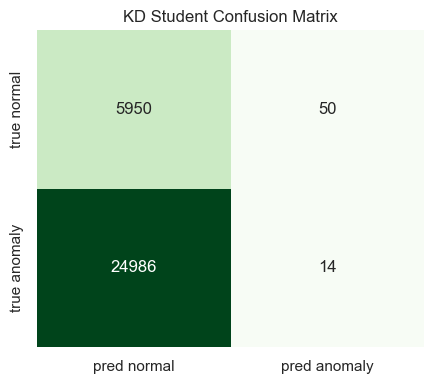

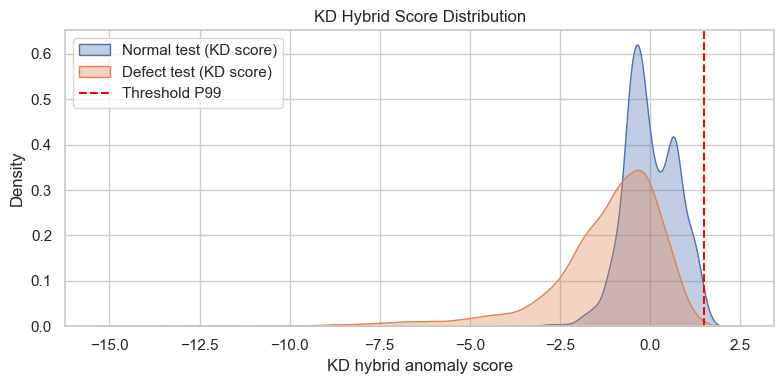


LNSA (KD): normal=5000, anomaly=250
Best KD threshold (LNSA by F1): 1.076571
              precision    recall  f1-score   support

      normal       0.95      0.92      0.93      5000
     anomaly       0.01      0.01      0.01       250

    accuracy                           0.88      5250
   macro avg       0.48      0.46      0.47      5250
weighted avg       0.90      0.88      0.89      5250



,threshold,precision,recall,f1
0,1.076571,0.005013,0.008,0.006163
1,1.077189,0.005013,0.008,0.006163
2,1.074950,0.004988,0.008,0.006144
3,1.073285,0.004975,0.008,0.006135
4,1.071979,0.004963,0.008,0.006126
5,1.069809,0.004938,0.008,0.006107
6,1.070396,0.004938,0.008,0.006107
7,1.070771,0.004938,0.008,0.006107
8,1.068961,0.004914,0.008,0.006088
9,1.067185,0.004890,0.008,0.006070


In [ ]:
# KD evaluation: hybrid score = student recon + lambda * teacher-student feature gap
def kd_recon_and_feat_errors(student_model, teacher_model, x, batch_size=256):
    student_model.eval()
    teacher_model.eval()
    recon_errs, feat_errs = [], []

    with torch.no_grad():
        for i in range(0, len(x), batch_size):
            xb = x[i:i + batch_size].to(DEVICE)

            s_recon, s_feat = student_model(xb)
            t_feat = teacher_model.encoder(xb)

            e_recon = ((s_recon - xb) ** 2).mean(dim=(1, 2, 3))

            if t_feat.shape[2:] != s_feat.shape[2:]:
                t_feat = F.adaptive_avg_pool2d(t_feat, s_feat.shape[2:])
            if t_feat.shape[1] != s_feat.shape[1]:
                t_feat = t_feat.mean(dim=1, keepdim=True).repeat(1, s_feat.shape[1], 1, 1)

            e_feat = ((s_feat - t_feat) ** 2).mean(dim=(1, 2, 3))

            recon_errs.append(e_recon.cpu())
            feat_errs.append(e_feat.cpu())

    return torch.cat(recon_errs).numpy(), torch.cat(feat_errs).numpy()

# Compute val/test components
val_recon_kd, val_feat_kd = kd_recon_and_feat_errors(student, teacher, X_val)
test_normal_recon_kd, test_normal_feat_kd = kd_recon_and_feat_errors(student, teacher, X_test_normal)
test_defect_recon_kd, test_defect_feat_kd = kd_recon_and_feat_errors(student, teacher, X_test_defect)

# Normalize by normal-validation stats then combine
eps = 1e-8
val_recon_z = (val_recon_kd - val_recon_kd.mean()) / (val_recon_kd.std() + eps)
val_feat_z = (val_feat_kd - val_feat_kd.mean()) / (val_feat_kd.std() + eps)

LAMBDA_FEAT = 0.65
val_score_kd = val_recon_z + LAMBDA_FEAT * val_feat_z

normal_recon_z = (test_normal_recon_kd - val_recon_kd.mean()) / (val_recon_kd.std() + eps)
normal_feat_z = (test_normal_feat_kd - val_feat_kd.mean()) / (val_feat_kd.std() + eps)
defect_recon_z = (test_defect_recon_kd - val_recon_kd.mean()) / (val_recon_kd.std() + eps)
defect_feat_z = (test_defect_feat_kd - val_feat_kd.mean()) / (val_feat_kd.std() + eps)

test_normal_score_kd = normal_recon_z + LAMBDA_FEAT * normal_feat_z
test_defect_score_kd = defect_recon_z + LAMBDA_FEAT * defect_feat_z

threshold_kd = np.percentile(val_score_kd, ANOMALY_PERCENTILE)
y_true_kd = np.concatenate([np.zeros(len(test_normal_score_kd), dtype=int), np.ones(len(test_defect_score_kd), dtype=int)])
scores_kd = np.concatenate([test_normal_score_kd, test_defect_score_kd])
y_pred_kd = (scores_kd > threshold_kd).astype(int)

print(f'KD threshold @ P{ANOMALY_PERCENTILE}: {threshold_kd:.6f}')
print(f'KD ROC-AUC: {roc_auc_score(y_true_kd, scores_kd):.4f}')
print(classification_report(y_true_kd, y_pred_kd, target_names=['normal', 'anomaly']))

cm_kd = confusion_matrix(y_true_kd, y_pred_kd)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm_kd, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['pred normal', 'pred anomaly'],
            yticklabels=['true normal', 'true anomaly'])
plt.title('KD Student Confusion Matrix')
plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 4))
sns.kdeplot(test_normal_score_kd, label='Normal test (KD score)', fill=True, alpha=0.35)
sns.kdeplot(test_defect_score_kd, label='Defect test (KD score)', fill=True, alpha=0.35)
plt.axvline(threshold_kd, color='red', linestyle='--', label=f'Threshold P{ANOMALY_PERCENTILE}')
plt.xlabel('KD hybrid anomaly score')
plt.ylabel('Density')
plt.title('KD Hybrid Score Distribution')
plt.legend()
plt.tight_layout(); plt.show()

# Optional LNSA threshold retuning for KD
N_NORMAL_LARGE_KD = min(5000, len(test_normal_score_kd))
N_ANOM_SMALL_KD = min(250, len(test_defect_score_kd))

rng_kd = np.random.default_rng(SEED)
idx_n = rng_kd.choice(len(test_normal_score_kd), size=N_NORMAL_LARGE_KD, replace=False)
idx_a = rng_kd.choice(len(test_defect_score_kd), size=N_ANOM_SMALL_KD, replace=False)

scores_lnsa_kd = np.concatenate([test_normal_score_kd[idx_n], test_defect_score_kd[idx_a]])
y_true_lnsa_kd = np.concatenate([np.zeros(N_NORMAL_LARGE_KD, dtype=int), np.ones(N_ANOM_SMALL_KD, dtype=int)])

q_grid_kd = np.linspace(90.0, 99.95, 320)
thr_grid_kd = np.unique(np.percentile(val_score_kd, q_grid_kd))
rows_kd = []
for t in thr_grid_kd:
    y_hat = (scores_lnsa_kd > t).astype(int)
    rows_kd.append({
        'threshold': float(t),
        'precision': precision_score(y_true_lnsa_kd, y_hat, zero_division=0),
        'recall': recall_score(y_true_lnsa_kd, y_hat, zero_division=0),
        'f1': f1_score(y_true_lnsa_kd, y_hat, zero_division=0),
    })

kd_thr_df = pd.DataFrame(rows_kd).sort_values(['f1', 'recall', 'precision'], ascending=[False, False, False]).reset_index(drop=True)
best_kd_thr = float(kd_thr_df.iloc[0]['threshold'])
best_kd_pred = (scores_lnsa_kd > best_kd_thr).astype(int)

print(f'\nLNSA (KD): normal={N_NORMAL_LARGE_KD}, anomaly={N_ANOM_SMALL_KD}')
print(f'Best KD threshold (LNSA by F1): {best_kd_thr:.6f}')
print(classification_report(y_true_lnsa_kd, best_kd_pred, target_names=['normal', 'anomaly']))
display(kd_thr_df.head(10))

Chosen KD rule: low-tail @ threshold=1.140743 (calib F1=0.8956)
Holdout metrics (unseen split):
              precision    recall  f1-score   support

      normal       0.69      0.07      0.12      4800
     anomaly       0.82      0.99      0.90     20000

    accuracy                           0.81     24800
   macro avg       0.75      0.53      0.51     24800
weighted avg       0.79      0.81      0.75     24800



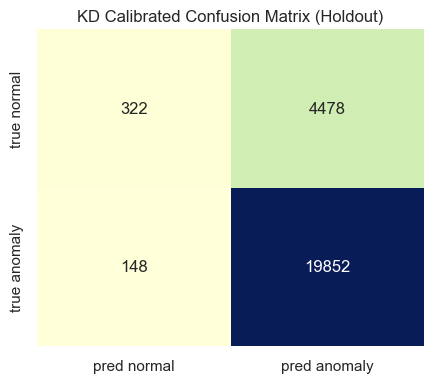

Full-set preview with calibrated KD rule:
              precision    recall  f1-score   support

      normal       0.69      0.07      0.12      6000
     anomaly       0.82      0.99      0.90     25000

    accuracy                           0.81     31000
   macro avg       0.75      0.53      0.51     31000
weighted avg       0.79      0.81      0.75     31000



In [48]:
# KD calibration fix: choose score direction + threshold on a small calibration split
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Build full KD score set (already computed above)
scores_all_kd = np.concatenate([test_normal_score_kd, test_defect_score_kd])
y_all_kd = np.concatenate([np.zeros(len(test_normal_score_kd), dtype=int), np.ones(len(test_defect_score_kd), dtype=int)])

# Stratified split: small calibration set, larger holdout evaluation set
idx_all = np.arange(len(y_all_kd))
idx_cal, idx_hold = train_test_split(
    idx_all, test_size=0.80, random_state=SEED, stratify=y_all_kd
)

scores_cal = scores_all_kd[idx_cal]
y_cal = y_all_kd[idx_cal]
scores_hold = scores_all_kd[idx_hold]
y_hold = y_all_kd[idx_hold]

# Search both tails and pick the best on calibration
thr_candidates = np.quantile(scores_cal, np.linspace(0.01, 0.99, 300))
best_cfg = None
for t in np.unique(thr_candidates):
    y_hat_hi = (scores_cal > t).astype(int)
    y_hat_lo = (scores_cal < t).astype(int)

    f1_hi = f1_score(y_cal, y_hat_hi, zero_division=0)
    f1_lo = f1_score(y_cal, y_hat_lo, zero_division=0)

    if best_cfg is None or f1_hi > best_cfg['f1']:
        best_cfg = {'mode': 'high-tail', 'threshold': float(t), 'f1': float(f1_hi)}
    if f1_lo > best_cfg['f1']:
        best_cfg = {'mode': 'low-tail', 'threshold': float(t), 'f1': float(f1_lo)}

# Apply chosen rule to holdout
if best_cfg['mode'] == 'high-tail':
    y_hold_pred = (scores_hold > best_cfg['threshold']).astype(int)
else:
    y_hold_pred = (scores_hold < best_cfg['threshold']).astype(int)

print(f"Chosen KD rule: {best_cfg['mode']} @ threshold={best_cfg['threshold']:.6f} (calib F1={best_cfg['f1']:.4f})")
print('Holdout metrics (unseen split):')
print(classification_report(y_hold, y_hold_pred, target_names=['normal', 'anomaly']))

cm_hold = confusion_matrix(y_hold, y_hold_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm_hold, annot=True, fmt='d', cmap='YlGnBu', cbar=False,
            xticklabels=['pred normal', 'pred anomaly'],
            yticklabels=['true normal', 'true anomaly'])
plt.title('KD Calibrated Confusion Matrix (Holdout)')
plt.tight_layout(); plt.show()

# Optional: apply calibrated rule to full set for deployment preview
if best_cfg['mode'] == 'high-tail':
    y_all_pred_kd_cal = (scores_all_kd > best_cfg['threshold']).astype(int)
else:
    y_all_pred_kd_cal = (scores_all_kd < best_cfg['threshold']).astype(int)

print('Full-set preview with calibrated KD rule:')
print(classification_report(y_all_kd, y_all_pred_kd_cal, target_names=['normal', 'anomaly']))